### MultiHead attention

In [1]:
import torch

#already tokenized and embedded 
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)
#create a batch
batch = torch.stack((inputs, inputs),dim=0) #batch of 2 sequences


In [2]:
from MultiHead_attention_class import MultiHeadAttentionWrapper

torch.manual_seed(123)
context_length = batch.shape[1] #6 tokens per batch
d_in, d_out = 3,2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads = 2
)
context_vecs = mha(batch)
print(context_vecs.shape) #should be (batch_size, context_length, d_out) = (2,6,2)
print(context_vecs)
#you are able to see that each token has 4 dimensions in the context vector. 

torch.Size([2, 6, 4])
tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5866,  0.0071,  0.5869,  0.3214],
         [-0.6293, -0.0621,  0.6184,  0.3825],
         [-0.5670, -0.0838,  0.5474,  0.3575],
         [-0.5519, -0.0979,  0.5319,  0.3423],
         [-0.5295, -0.1077,  0.5074,  0.3481]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5866,  0.0071,  0.5869,  0.3214],
         [-0.6293, -0.0621,  0.6184,  0.3825],
         [-0.5670, -0.0838,  0.5474,  0.3575],
         [-0.5519, -0.0979,  0.5319,  0.3423],
         [-0.5295, -0.1077,  0.5074,  0.3481]]], grad_fn=<CatBackward0>)


notice that even though d_out is 2 it is 4 because 
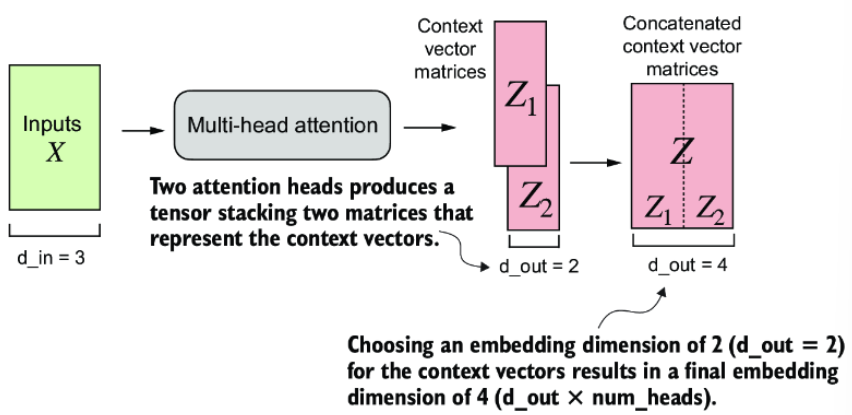

### Optimized 

##### Example to help understand the transpose and reasoning

In [3]:
import torch

a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573],
                    [0.8993, 0.0390, 0.9268, 0.7388],
                    [0.7179, 0.7058, 0.9156, 0.4340]],

                   [[0.0772, 0.3565, 0.1479, 0.5331],
                    [0.4066, 0.2318, 0.4545, 0.9737],
                    [0.4606, 0.5159, 0.4220, 0.5786]]]])

In [4]:
#matrix multiplication of a and its transpose(swapped last 2 columns)
print(a @ a.transpose(2,3))

tensor([[[[1.3208, 1.1631, 1.2879],
          [1.1631, 2.2150, 1.8424],
          [1.2879, 1.8424, 2.0402]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])


In [5]:
first_head = a[0,0,:,:]
first_res = first_head @first_head.T
print (first_head)
print("First head:" ,first_res)

second__head = a[0,1,:,:]
second_res = second__head @ second__head.T
print (second__head)
print("Second head:" ,second_res)

#notice it is the same as the above transpose
#it shows that we can parallelize and get the same result as doing it sequentially.

tensor([[0.2745, 0.6584, 0.2775, 0.8573],
        [0.8993, 0.0390, 0.9268, 0.7388],
        [0.7179, 0.7058, 0.9156, 0.4340]])
First head: tensor([[1.3208, 1.1631, 1.2879],
        [1.1631, 2.2150, 1.8424],
        [1.2879, 1.8424, 2.0402]])
tensor([[0.0772, 0.3565, 0.1479, 0.5331],
        [0.4066, 0.2318, 0.4545, 0.9737],
        [0.4606, 0.5159, 0.4220, 0.5786]])
Second head: tensor([[0.4391, 0.7003, 0.5903],
        [0.7003, 1.3737, 1.0620],
        [0.5903, 1.0620, 0.9912]])


##### With our actual data

In [6]:
from MultiHead_attention_class import MultiHeadAttention

torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads = 2)
context_vecs = mha(batch)
print(context_vecs.shape) #should be (batch_size, context_length, d_out) = (2,6,2)
print(context_vecs)



torch.Size([2, 6, 2])
tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
